In [1]:
# EDA
import pandas as pd
import statsmodels.api as sm 
import plotly.express as px 
import matplotlib.pyplot as plt
import sweetviz as sv

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score

# Hyperparameters Optimization
import optuna

# Exploratory Data Analysis - EDA

## Loading the data

In [2]:
# Load dataset
df_obesity = pd.read_csv('./datasets/dataset_obesity.csv')

df_obesity.head(10)

,Male,Age,Family_History_of_Overweight,Frequent_High_Calorie_Intake,Frequent_Vegetable_Intake,Daily_Meals,Snacking_Between_Meals,Smoker,Water_Consumption,Monitors_Calorie_Intake,Physical_Activity_Level,Screen_Time,Alcohol_Consumption,Car_Transportation,Bicycle_Transportation,Motorcycle_Transportation,Public_Transportation,Walking,Obese
0,0,21.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,0,0,0,1,0,0
1,0,21.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,0,0,0,1,0,0
2,1,23.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,0,0,0,1,0,0
3,1,27.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,0,0,0,0,1,0
4,1,22.0,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,0,0,0,1,0,0
5,1,29.0,0,1,2.0,3.0,1,0,2.0,0,0.0,0.0,1,1,0,0,0,0,0
6,0,23.0,1,1,3.0,3.0,1,0,2.0,0,1.0,0.0,1,0,0,1,0,0,0
7,1,22.0,0,0,2.0,3.0,1,0,2.0,0,3.0,0.0,1,0,0,0,1,0,0
8,1,24.0,1,1,3.0,3.0,1,0,2.0,0,1.0,1.0,2,0,0,0,1,0,0
9,1,22.0,1,1,2.0,3.0,1,0,2.0,0,1.0,1.0,0,0,0,0,1,0,0


In [3]:
df_obesity.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Male                          2111 non-null   int64  
 1   Age                           2111 non-null   float64
 2   Family_History_of_Overweight  2111 non-null   int64  
 3   Frequent_High_Calorie_Intake  2111 non-null   int64  
 4   Frequent_Vegetable_Intake     2111 non-null   float64
 5   Daily_Meals                   2111 non-null   float64
 6   Snacking_Between_Meals        2111 non-null   int64  
 7   Smoker                        2111 non-null   int64  
 8   Water_Consumption             2111 non-null   float64
 9   Monitors_Calorie_Intake       2111 non-null   int64  
 10  Physical_Activity_Level       2111 non-null   float64
 11  Screen_Time                   2111 non-null   float64
 12  Alcohol_Consumption           2111 non-null   int64  
 13  Car_Transporta

In [4]:
# Convert features to int
features_list = ["Age", "Frequent_Vegetable_Intake", "Daily_Meals", "Water_Consumption", "Physical_Activity_Level", "Screen_Time"]

df_obesity[features_list] = df_obesity[features_list].astype(int)

## Numeric Features

In [5]:
# Target feature distribuition
px.bar(df_obesity.value_counts('Obese'))

In [6]:
px.bar((df_obesity.value_counts('Obese') / len(df_obesity)) * 100)

In [7]:
px.histogram(df_obesity, x="Age")

## Categorical Features

In [11]:
px.bar(df_obesity.value_counts("Male") / len(df_obesity) * 100)

In [12]:
px.bar(df_obesity.value_counts("Family_History_of_Overweight") / len(df_obesity) * 100)

In [13]:
px.bar(df_obesity.value_counts("Physical_Activity_Level") / len(df_obesity) * 100)

In [14]:
px.bar(df_obesity.value_counts("Screen_Time") / len(df_obesity) * 100)

### Hypothesis Formulations

#### Age group influences obesity

In [16]:
df_obesity.Age.describe()

count    2111.000000
mean       23.972525
std         6.308664
min        14.000000
25%        19.000000
50%        22.000000
75%        26.000000
max        61.000000
Name: Age, dtype: float64

In [19]:
# Age bucketing
bins = [10,20,30,40,50,60,70]
ordinal_bins = [0, 1, 2, 3, 4, 5]

age_group_labels = ['10-19', '20-29', '30-39', '40-49', '50-59', '60-69']

df_obesity['Age_Group_String'] = pd.cut(x = df_obesity.Age, bins=bins, labels=age_group_labels, include_lowest=True)
df_obesity['Age_Group'] = pd.cut(x = df_obesity.Age, bins=bins, labels=ordinal_bins, include_lowest=True)

df_obesity.head(10)

,Male,Age,Family_History_of_Overweight,Frequent_High_Calorie_Intake,Frequent_Vegetable_Intake,Daily_Meals,Snacking_Between_Meals,Smoker,Water_Consumption,Monitors_Calorie_Intake,...,Screen_Time,Alcohol_Consumption,Car_Transportation,Bicycle_Transportation,Motorcycle_Transportation,Public_Transportation,Walking,Obese,Age_Group_String,Age_Group
0,0,21,1,0,2,3,1,0,2,0,...,1,0,0,0,0,1,0,0,20-29,1
1,0,21,1,0,3,3,1,1,3,1,...,0,1,0,0,0,1,0,0,20-29,1
2,1,23,1,0,2,3,1,0,2,0,...,1,2,0,0,0,1,0,0,20-29,1
3,1,27,0,0,3,3,1,0,2,0,...,0,2,0,0,0,0,1,0,20-29,1
4,1,22,0,0,2,1,1,0,2,0,...,0,1,0,0,0,1,0,0,20-29,1
5,1,29,0,1,2,3,1,0,2,0,...,0,1,1,0,0,0,0,0,20-29,1
6,0,23,1,1,3,3,1,0,2,0,...,0,1,0,0,1,0,0,0,20-29,1
7,1,22,0,0,2,3,1,0,2,0,...,0,1,0,0,0,1,0,0,20-29,1
8,1,24,1,1,3,3,1,0,2,0,...,1,2,0,0,0,1,0,0,20-29,1
9,1,22,1,1,2,3,1,0,2,0,...,1,0,0,0,0,1,0,0,20-29,1


In [21]:
# Create a Contingence Table - Age Group X Obese
contingence_table_age_group = sm.stats.Table.from_data(df_obesity[["Obese", "Age_Group_String"]])
contingence_table_age_group.table_orig

Age_Group_String,10-19,20-29,30-39,40-49,50-59,60-69
Obese,,,,,,
0,498,489,131,13,7,1
1,176,649,127,19,1,0


In [22]:
# Pearson Chi-Square Test
print(contingence_table_age_group.test_nominal_association())

df          5
pvalue      0.0
statistic   170.1116865347508


p_value < 0.05, reject h0, so the features aren't independent

## Automatizating the EDA

In [23]:
sv_obesity_report = sv.analyze(df_obesity, target_feat="Obese")

                                             |          | [  0%]   00:00 -> (? left)


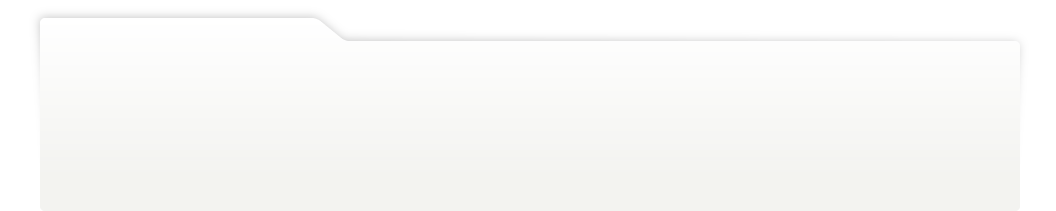
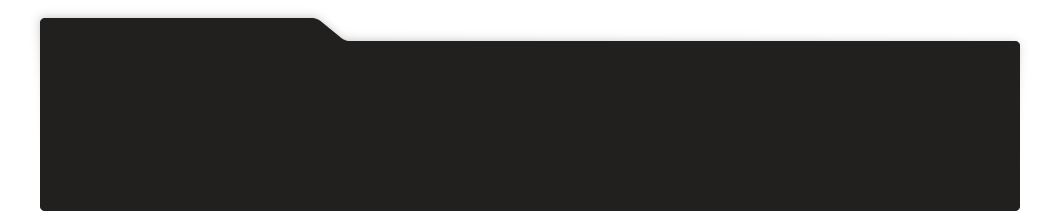
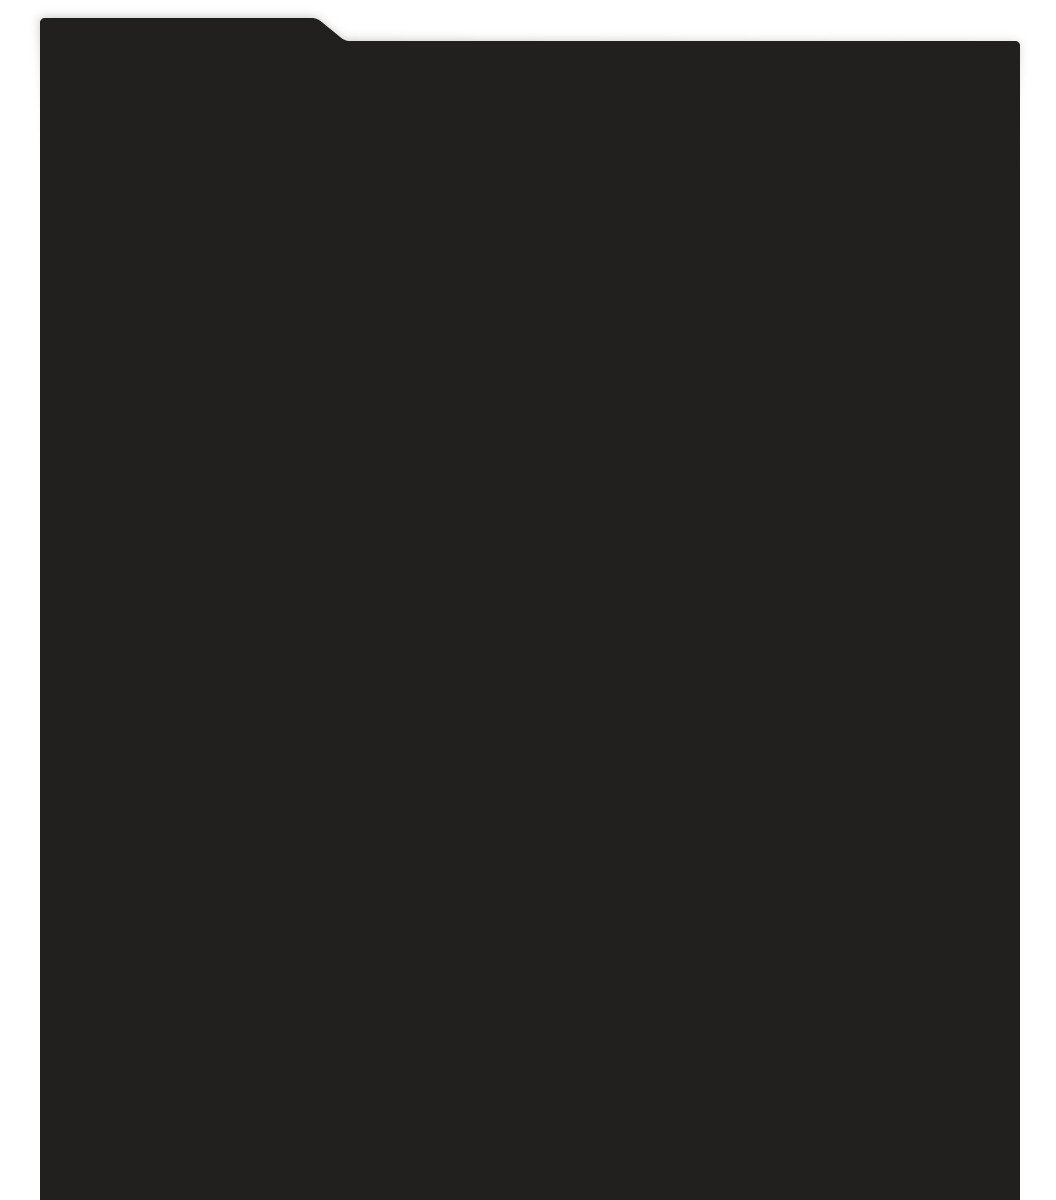
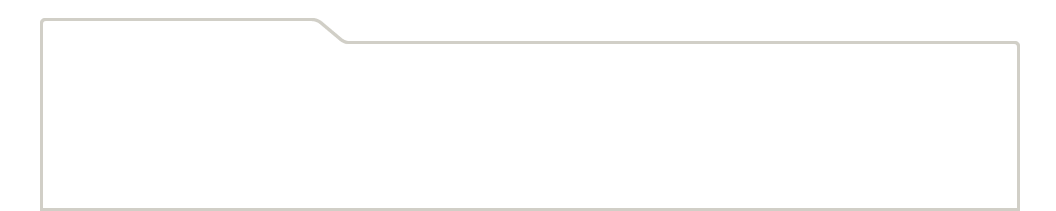
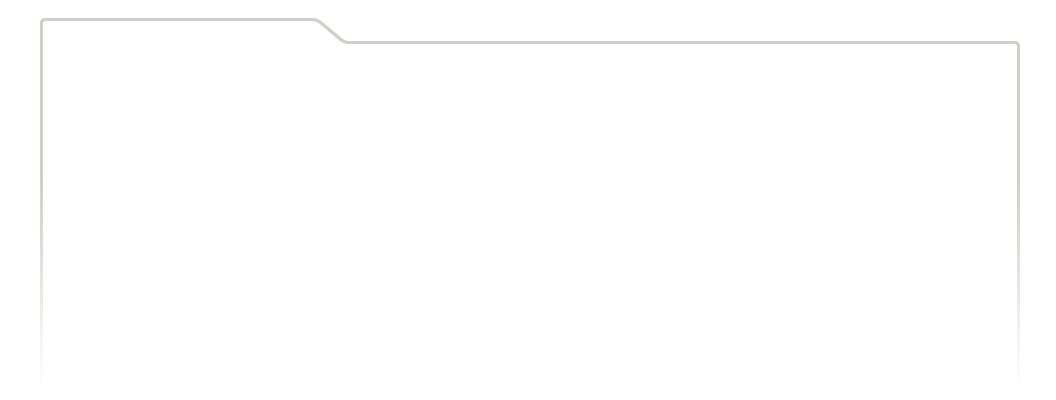
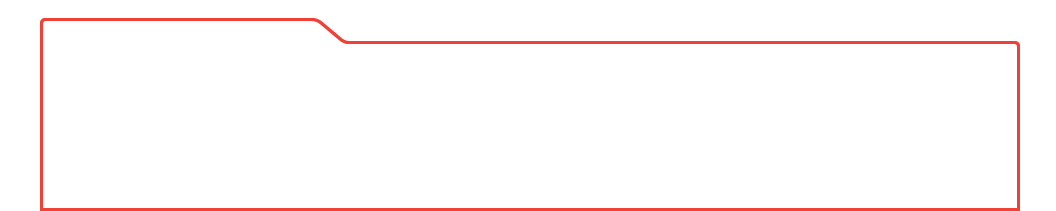
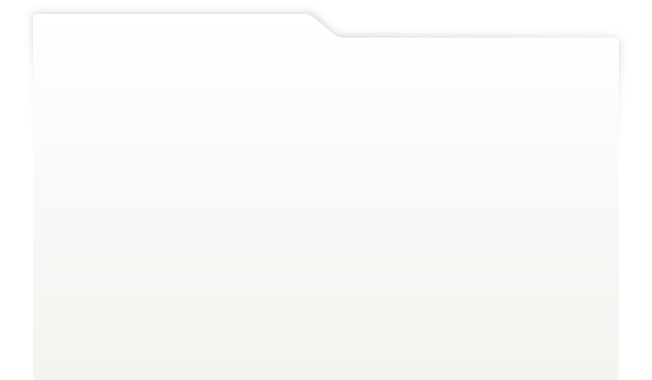
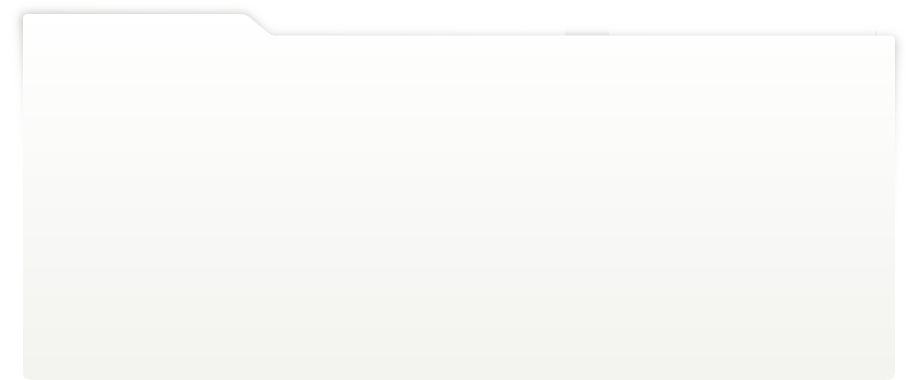
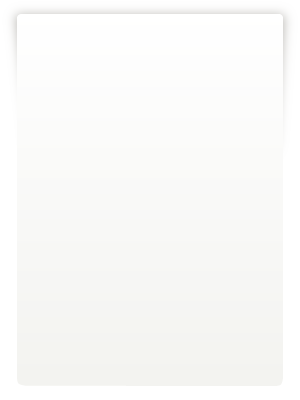
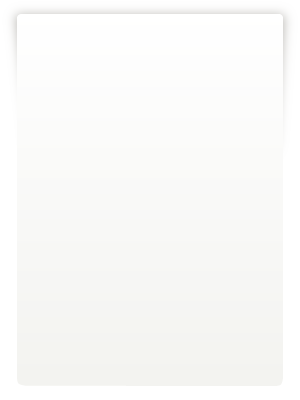
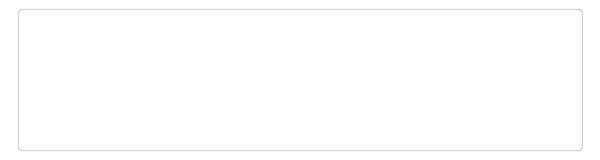
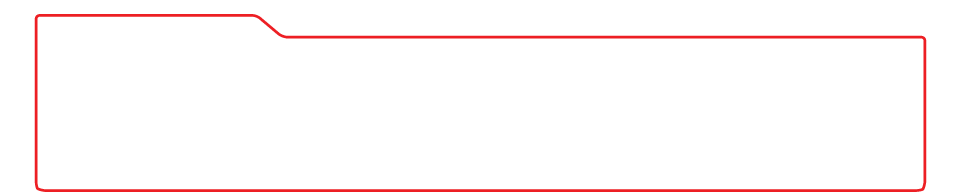
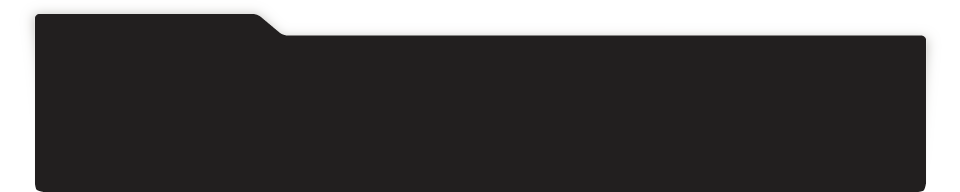
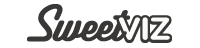
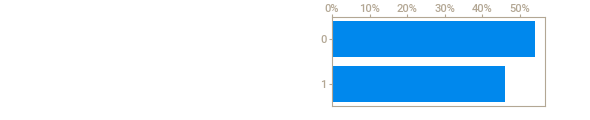
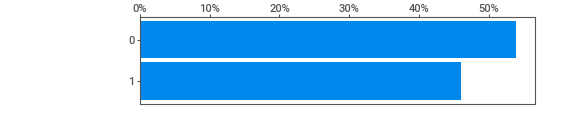
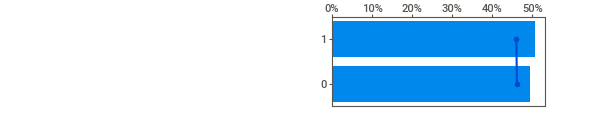
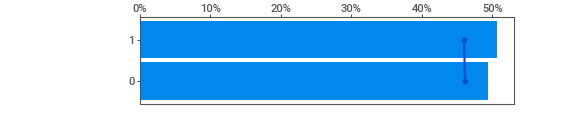
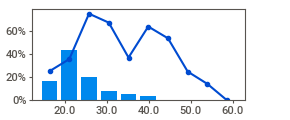
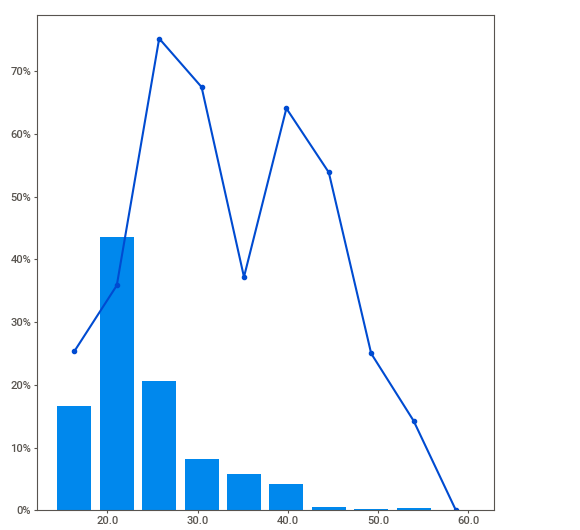
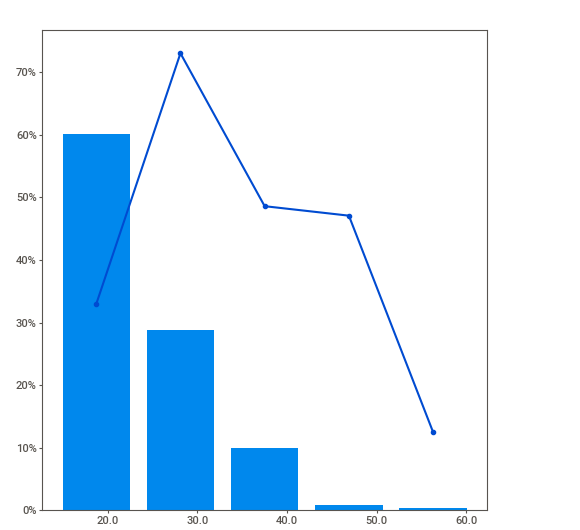
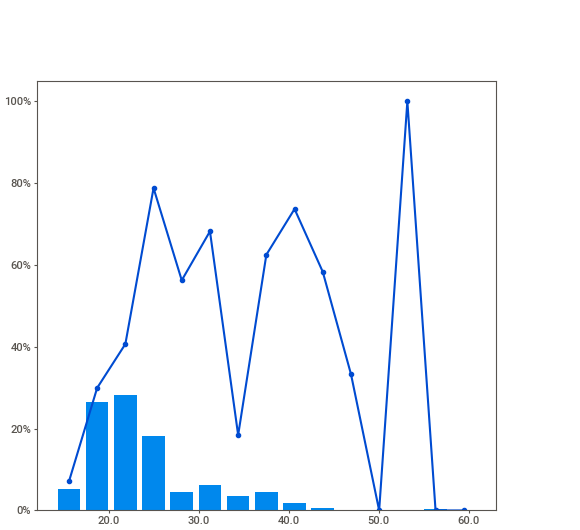
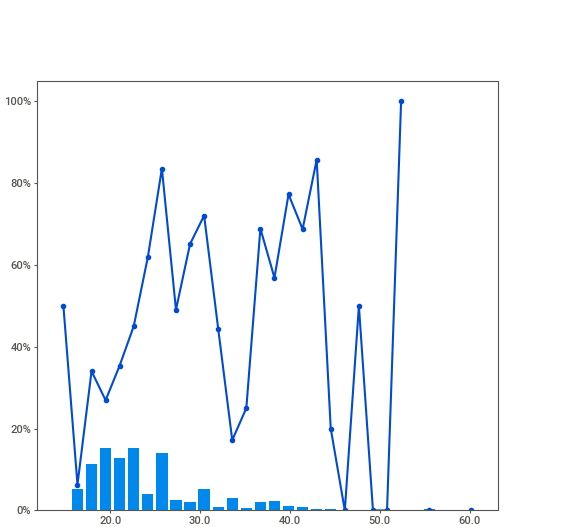
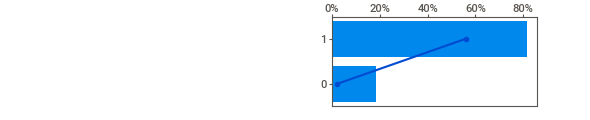
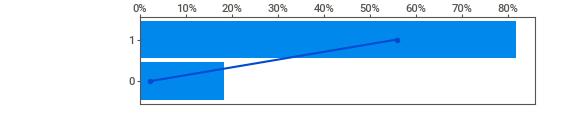
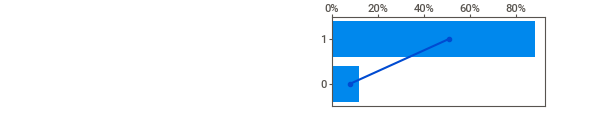
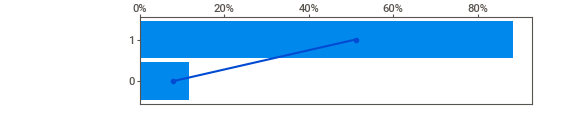
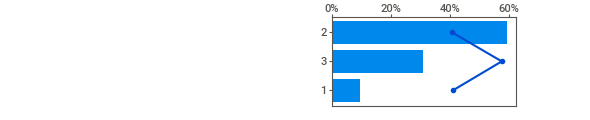
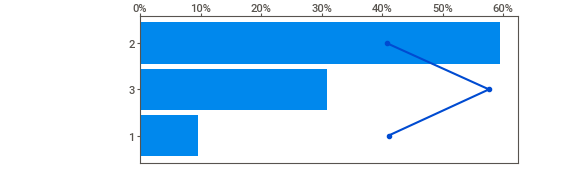
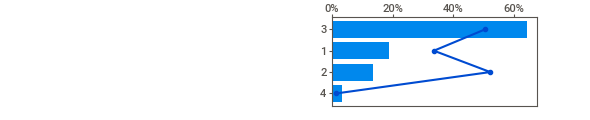
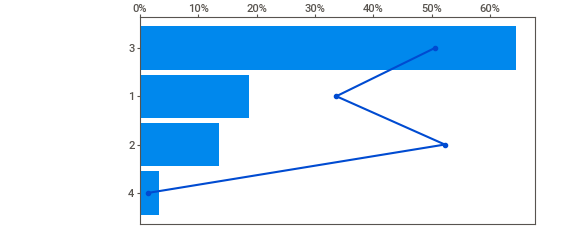
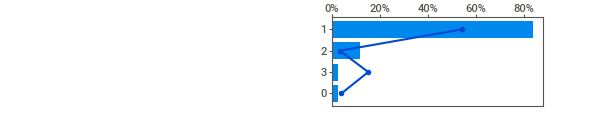
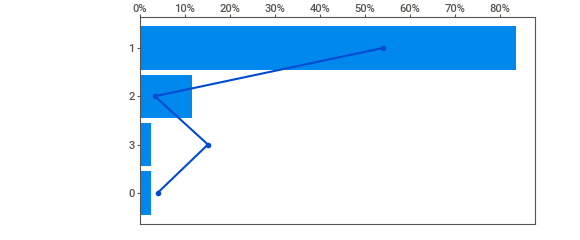
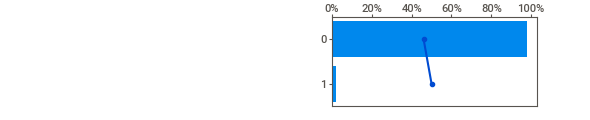
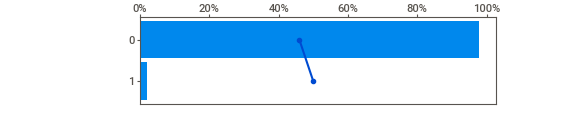
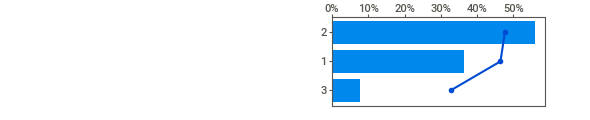
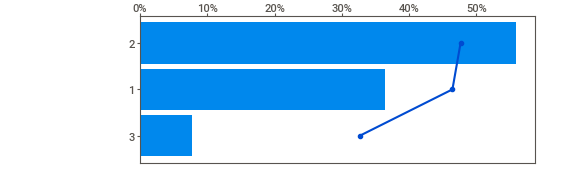
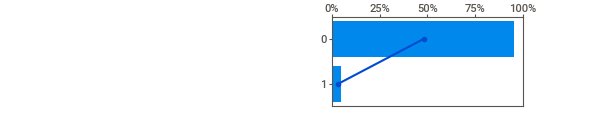
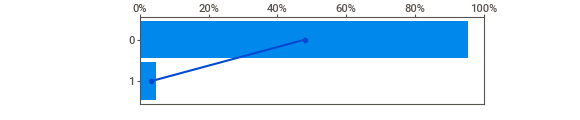
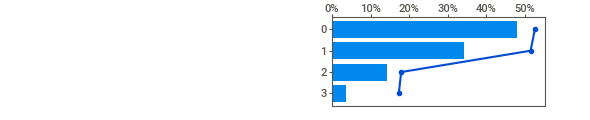
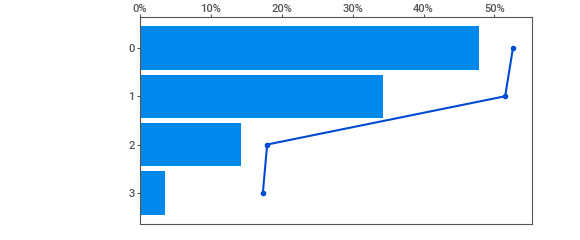
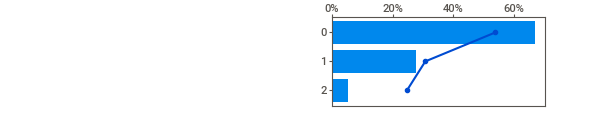
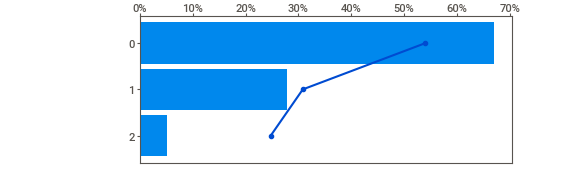
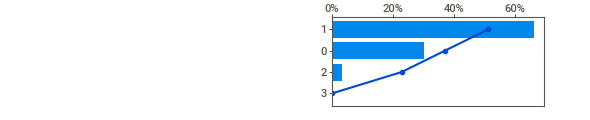
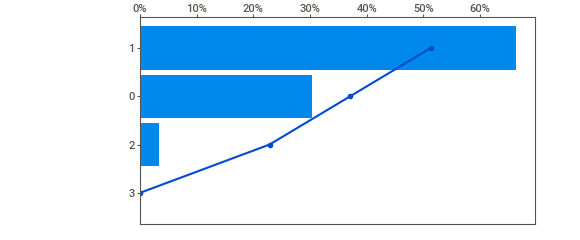
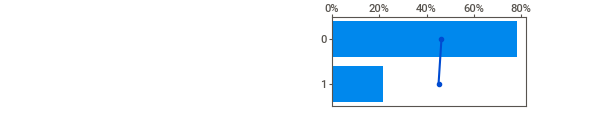
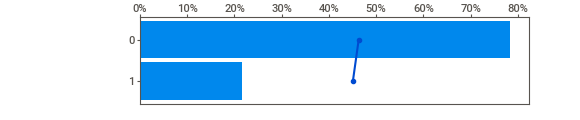
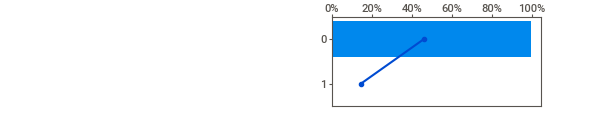
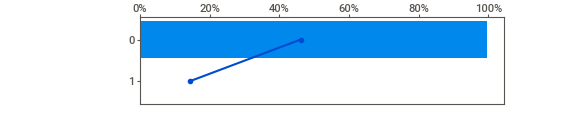
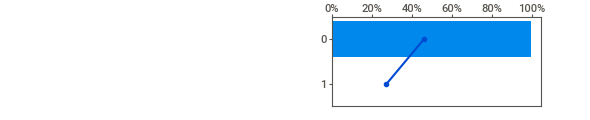
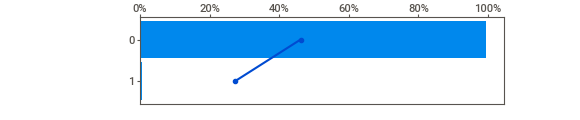
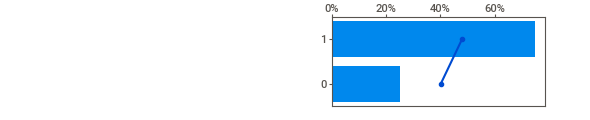
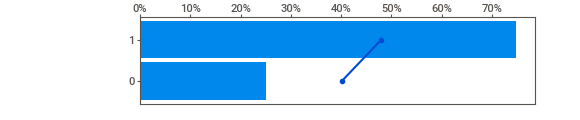
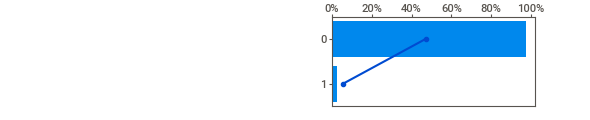
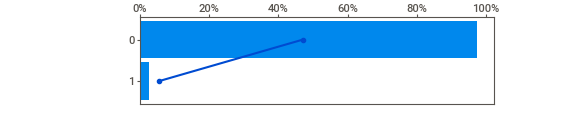
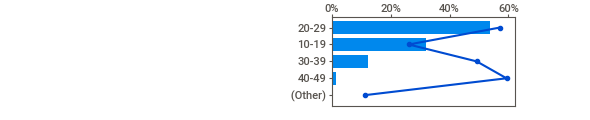
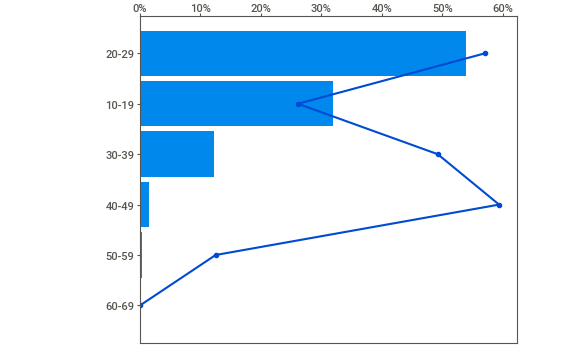
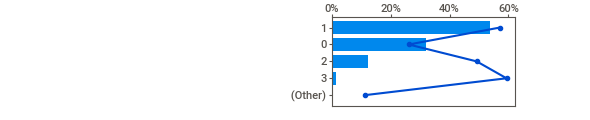
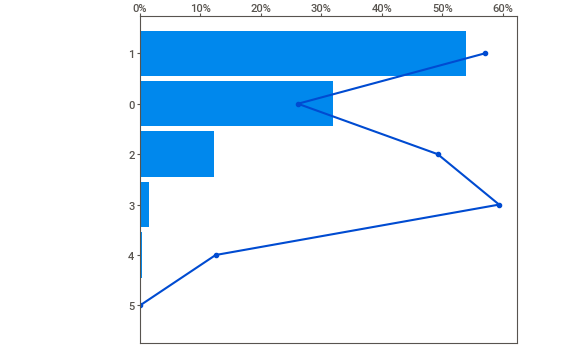
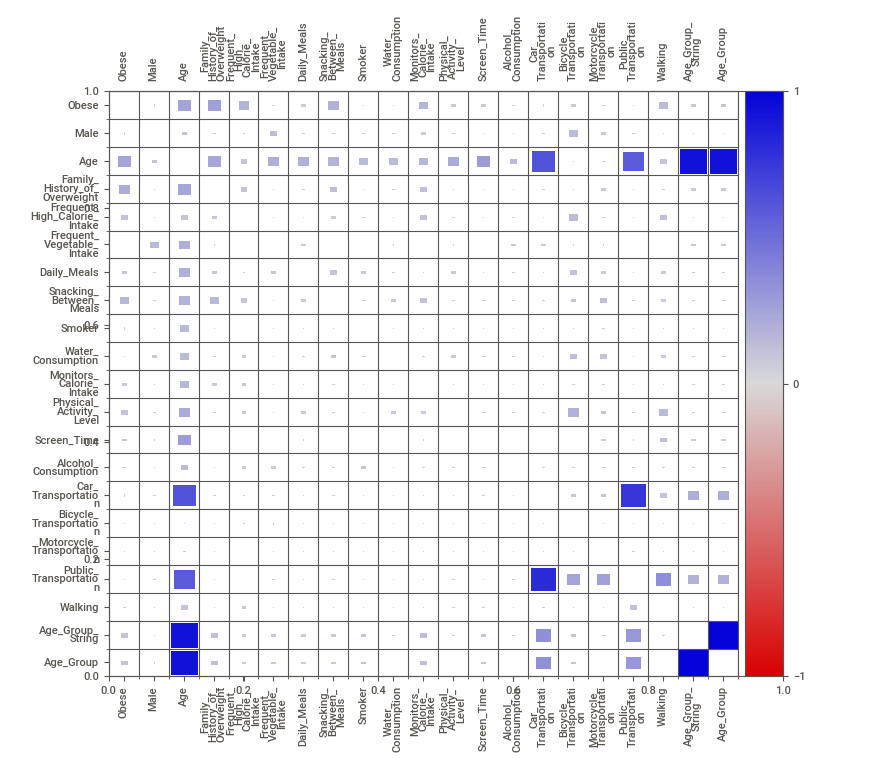
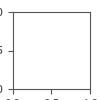

In [24]:
sv_obesity_report.show_notebook()